In [1]:
# load packages needed for decision tree and random forest regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# load clean data in — baseline feature set 
CRMLSSold_cleaned = pd.read_csv('data/cleaned_CRMLSSOLD_baseline.csv')
print(CRMLSSold_cleaned.info())
CRMLSSold_cleaned.head()

<class 'pandas.DataFrame'>
RangeIndex: 67226 entries, 0 to 67225
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CloseDate              67226 non-null  str    
 1   ClosePrice             67226 non-null  float64
 2   LivingArea             67226 non-null  float64
 3   BedroomsTotal          67226 non-null  int64  
 4   BathroomsTotalInteger  67226 non-null  int64  
 5   YearBuilt              67226 non-null  int64  
 6   GarageSpaces           64794 non-null  float64
 7   LotSizeSquareFeet      66037 non-null  float64
 8   CountyOrParish         67226 non-null  str    
 9   Latitude               67226 non-null  float64
 10  Longitude              67226 non-null  float64
 11  PoolPrivateYN          67226 non-null  str    
 12  ViewYN                 67226 non-null  str    
 13  FireplaceYN            67226 non-null  str    
 14  NewConstructionYN      67226 non-null  str    
 15  HasAssociatio

,CloseDate,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,GarageSpaces,LotSizeSquareFeet,CountyOrParish,Latitude,Longitude,PoolPrivateYN,ViewYN,FireplaceYN,NewConstructionYN,HasAssociationFee
0,2025-11-30,1250000.0,1027.0,3,2,1961,2.0,5913.0,Orange,33.676050,-117.995210,False,False,False,False,False
1,2025-11-20,2299995.0,1129.0,3,1,1949,2.0,18432.0,Santa Clara,37.260693,-121.934121,Unknown,False,True,False,Unknown
2,2025-11-26,810000.0,1619.0,4,3,1978,2.0,5300.0,San Diego,32.564997,-117.064393,False,False,True,Unknown,False
3,2025-11-17,925000.0,2872.0,5,3,2000,3.0,5272.0,San Diego,32.575778,-117.024433,False,False,True,Unknown,True
4,2025-11-25,1300000.0,1727.0,3,2,1950,3.0,10500.0,San Luis Obispo,35.553064,-120.708510,False,False,True,False,False


### train/test function

In [3]:
# Same time-based train/test split as 03_baseline_model.ipynb
def make_train_test_split(df, feature_cols, training_months=None):
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])
    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    test_month  = df['CloseMonth'].max()
    train_start = test_month - training_months if training_months else df['CloseMonth'].min()

    train = df[(df['CloseMonth'] >= train_start) & (df['CloseMonth'] < test_month)].copy()
    test  = df[df['CloseMonth'] == test_month].copy()

    X_train = train[feature_cols]
    y_train = train['ClosePrice']
    X_test  = test[feature_cols]
    y_test  = test['ClosePrice']

    print(f"Test month:  {test_month}")
    print(f"Train range: {train['CloseMonth'].min()} to {train['CloseMonth'].max()}  ({train['CloseMonth'].nunique()} months)")
    print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

    return X_train, y_train, X_test, y_test

In [4]:
# Features and preprocessing — trees don't need scaling or log transforms,
# but we keep log(ClosePrice) so R^2 is directly comparable to the baseline model
feature_cols = [col for col in CRMLSSold_cleaned.columns if col != 'ClosePrice']
categorical_cols = ['PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'NewConstructionYN',
                    'HasAssociationFee', 'CountyOrParish']
numeric_cols = ['LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
                'YearBuilt', 'GarageSpaces', 'Latitude', 'Longitude']

CRMLSSold_cleaned['ClosePrice'] = np.log(CRMLSSold_cleaned['ClosePrice'])

# numeric columns only need median imputation (GarageSpaces, LotSizeSquareFeet) — no scaling needed for trees
preprocessor = ColumnTransformer([
    ('impute', SimpleImputer(strategy='median'), numeric_cols),
    ('encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train, y_train, X_test, y_test = make_train_test_split(
    CRMLSSold_cleaned, feature_cols, training_months=None
)

Test month:  2026-05
Train range: 2025-11 to 2026-04  (6 months)
X_train: (55890, 15)  |  X_test: (11336, 15)


### Fit model and model comparison plot/ Post Model Plots

In [5]:
# Fit Decision Tree and Random Forest with default hyperparameters,
# evaluate once on the held-out test month.
model_classes = {'DecisionTree': DecisionTreeRegressor, 'RandomForest': RandomForestRegressor}

results = {}
for name, model_class in model_classes.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_class(random_state=42))
    ])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    results[name] = {'pipeline': pipeline, 'r2': r2, 'rmse': rmse}
    print(f"{name}")
    print(f"  Test R^2:               {r2:.4f}")
    print(f"  Test RMSE (log price):  {rmse:.4f}\n")

DecisionTree
  Test R^2:               0.8296
  Test RMSE (log price):  0.2528

RandomForest
  Test R^2:               0.9152
  Test RMSE (log price):  0.1783



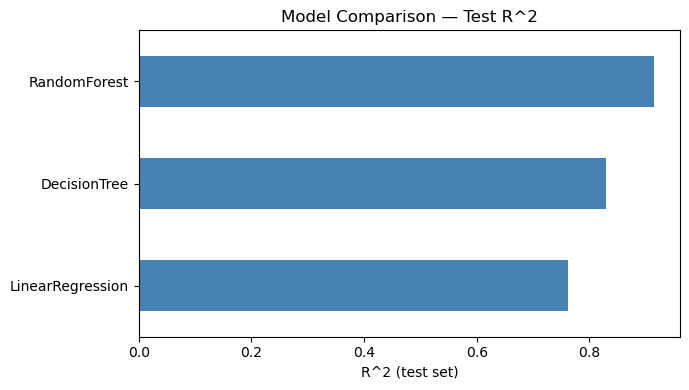

In [6]:
# R^2 comparison chart — linear baseline value hardcoded from 03_baseline_model.ipynb
baseline_r2 = 0.7618
comparison = pd.Series({'LinearRegression': baseline_r2,
                        'DecisionTree': results['DecisionTree']['r2'],
                        'RandomForest': results['RandomForest']['r2']}).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
comparison.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('R^2 (test set)')
ax.set_title('Model Comparison — Test R^2')
plt.tight_layout()
plt.show()

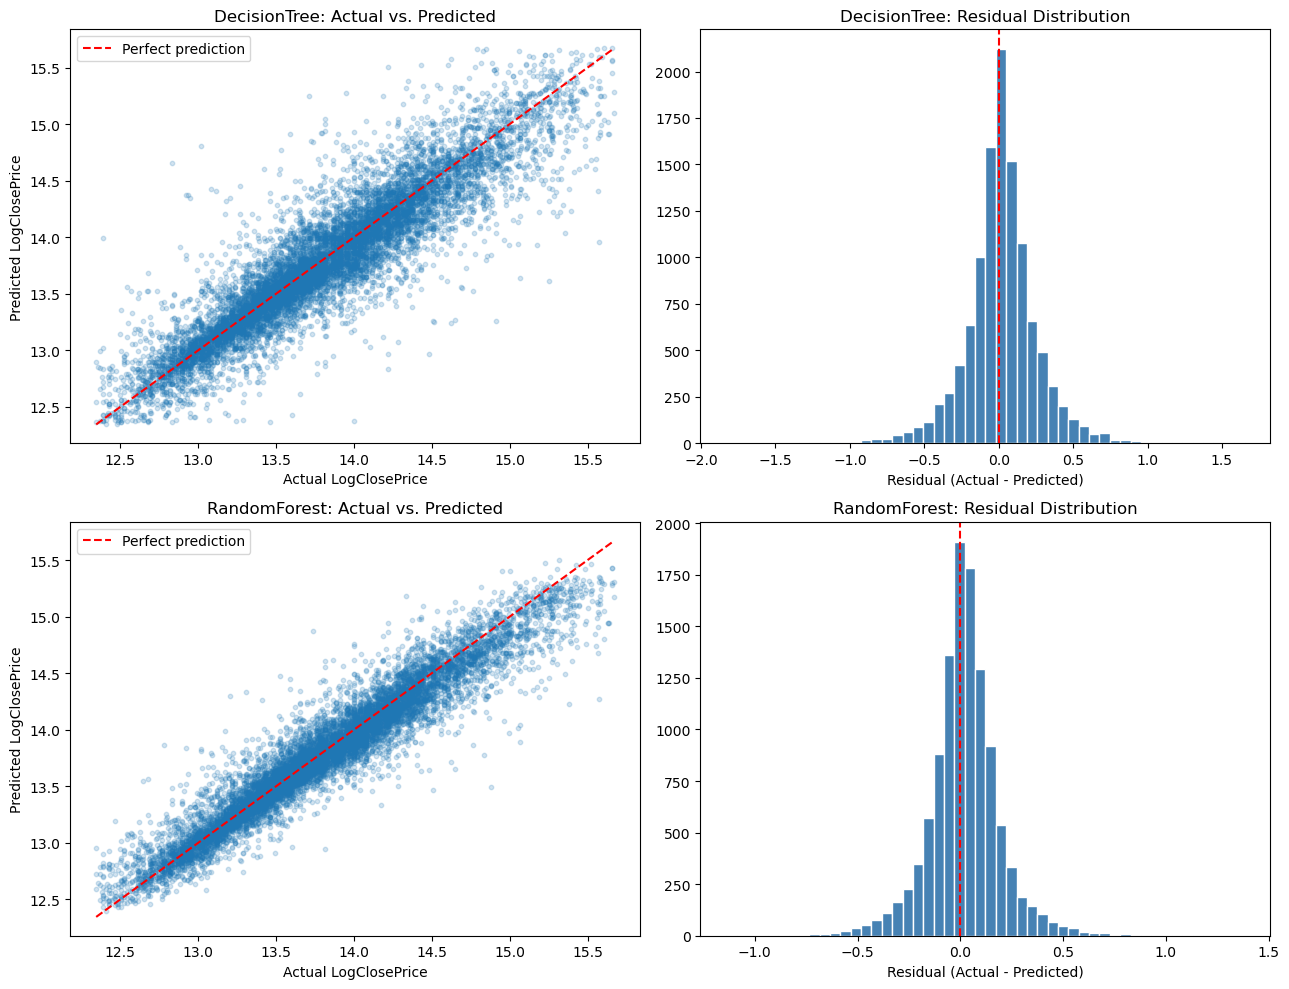

In [7]:
# Post-model diagnostics — actual vs. predicted and residual distribution, per model
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (name, res) in enumerate(results.items()):
    preds = res['pipeline'].predict(X_test)
    residuals = y_test - preds

    ax_scatter = axes[row, 0]
    ax_scatter.scatter(y_test, preds, alpha=0.2, s=10)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax_scatter.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
    ax_scatter.set_xlabel('Actual LogClosePrice')
    ax_scatter.set_ylabel('Predicted LogClosePrice')
    ax_scatter.set_title(f'{name}: Actual vs. Predicted')
    ax_scatter.legend()

    ax_hist = axes[row, 1]
    ax_hist.hist(residuals, bins=50, color='steelblue', edgecolor='white')
    ax_hist.axvline(0, color='red', linestyle='--')
    ax_hist.set_xlabel('Residual (Actual - Predicted)')
    ax_hist.set_title(f'{name}: Residual Distribution')

plt.tight_layout()
plt.show()